# Зеркальный спуск  

## Основная часть

__Задача 1. (10 баллов)__ Рассмотрим следующую билинейную задачу на симплексах:
$$
\min_{x \in \mathcal{X}} \max_{y \in \mathcal{Y}} f(x,y) = x^T A y,
$$
где $X = \{ x \in \mathbb{R}^d \mid x_i \geq 0 , \sum_{i=1}^d x_i = 1\}$, $Y = \{ y \in \mathbb{R}^d \mid y_i \geq 0 , \sum_{i=1}^d x_i = 1\}$, $A \in \mathbb{R^{d \times d}}$.

Такую задачу часто называют матричной игрой. В этом задании будет конкретная игра "Вор и полицейский".

Пусть город представляет собой квадрат из $n \times n$ маленьких квадратиков. В каждом квадратике стоит дом и полицейская будка рядом с ним. Пусть так же известны ценность дома для вора $w_{i}$ в квадрате $i$. Каждую ночь вор выбирает, какой дом ограбить, а полицейский выбирает будку, в которой будет дежурить. Вероятность поимки вора, если вор грабит дом в квадрате $j$, а полисмен дежурит в квадрате $i$ равна:
    $$\exp(- \alpha  \cdot \text{dist}(i,j)).$$
Здесь $\alpha > 0$ - некторый параметр, т.е. вероятность уменьшается с увеличением расстояния между квадратами.
Вор хочет максимизировать свою ожидаемую прибыль:
    $$w_j \left(1 -  \exp(- \alpha \cdot \text{dist}(i,j))\right).$$
Полицейский наоборот - минимизировать.

Такую постановку можно формализовать в виде матричной игры: занумеруем все дома от $0$ до $d = n^2 - 1$, получится вектор $w \in \mathbb{R}^{d}$ стоимостей домов. В элемент $A_{ij}$ матрицы $A$ запишем:
$$A_{ij} = w_j \left(1 - \exp(- \alpha \cdot \text{dist}(i,j))\right),$$
т.е. ожидаемую прибыль вора, если он будет грабить дом с номером $j$, а полицейский дежурить в доме с номером $i$. В векторах $x$ и $y$ будут хранится вероятностные стратегии для полицийского и вора: вероятность выбрать тот или иной дом для дежурства или грабежа. Цель задания найти равновестные стратегии.

Возьмем $n = 10$. Следующий код генерирует некоторое распределение ценностей домов $w$ и матрицу $A$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [ ]:
def dist(i, j, n):
    i_x = i % n
    i_y = i // n
    j_x = j % n
    j_y = j // n
    return np.linalg.norm([i_x - j_x, i_y - j_y], 2)

def game(n = 10):
    i_max = (n // 2) * (n + 1)
    w = np.array([1. / (dist(i, i_max, n) + 20) for i in range(n ** 2)])
    A = np.zeros([n ** 2, n ** 2])
    for i in range(n ** 2):
        for j in range(n ** 2):
            A[i,j] = w[j] * (1 - np.exp(- dist(i, j, n)))
    return A, w

In [ ]:
n = 10
A, w = game(n)

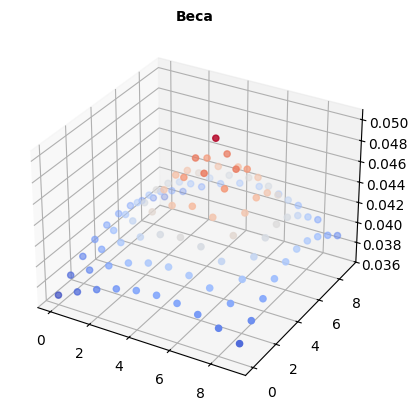

In [ ]:
X, Y = np.meshgrid(range(n), range(n))
X = X.ravel()
Y = Y.ravel()

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X, Y, w, c = w, cmap=cm.coolwarm)
ax.set_title(f"Веса", fontsize = 10, fontweight='bold')

plt.show()

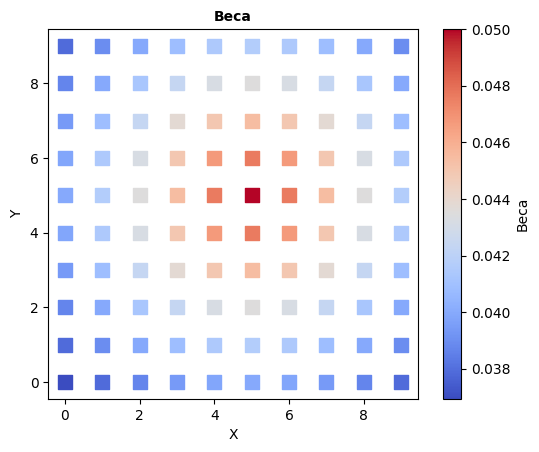

In [ ]:
fig, ax = plt.subplots()

sc = ax.scatter(X, Y, c=w, cmap='coolwarm', marker='s', s=100)
ax.set_aspect('equal', adjustable='box')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Веса')

ax.set_title("Веса", fontsize=10, fontweight='bold')
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

На графиках выше визуализированны стоимости домов в городе: в центре самые дорогие, на окраинах бедные.


На лекциях мы познакомились с экстраградиентным методом и зеркальным спуском. Первый предназначен для решения седловых задач, второй - для лучшего учета "геометрии" задачи. Попробуем объединить эти две идеи и получим следующий метод:
\begin{align}
x^{k+1/2} &= \arg\min_{x \in \mathcal{X}} (\gamma\langle \nabla_x f(x^k, y^k), x\rangle + V(x,x^k))
\\
y^{k+1/2} &= \arg\min_{y \in \mathcal{Y}} (\gamma\langle - \nabla_y f(x^k, y^k), y\rangle + V(y,y^k))
\\
x^{k+1} &= \arg\min_{x \in \mathcal{X}} (\gamma\langle \nabla_x f(x^{k+1/2}, y^{k+1/2}), x\rangle + V(x,x^k))
\\
y^{k+1} &= \arg\min_{y \in \mathcal{Y}} (\gamma\langle - \nabla_y f(x^{k+1/2}, y^{k+1/2}), y\rangle + V(y,y^k)),
\end{align}
где $\gamma > 0$ - шаг метода.
Для краткости введем обозначения, как на лекции:
$$
z = \binom{x}{y} \quad F(z) = F(x,y) = \binom{\nabla_x f(x, y)}{- \nabla_y f(x, y)}
$$
В новых обозначениях метод выше можно переписать, как
\begin{align}
z^{k+1/2} &= \arg\min_{z \in \mathcal{Z}} (\gamma\langle F(z^k), z\rangle + V(z,z^k))
\\
z^{k+1} &= \arg\min_{z \in \mathcal{Z}} (\gamma\langle F(z^{k+1/2}), z\rangle + V(z,z^k)).
\end{align}

Пусть оператор $F$ является $L$-Липшицевым (следует из Липшицевости градиентов):
$$
\| F(z_1) - F(z_2) \|_* \leq L \| z_1 - z_2\|,
$$
а функция $f$ является выпукло-вогнутой.

__а). (3 балла)__ Для игровой задачи запишите явный вид метода, (на лекции мы тоже работали с симплексом). Реализуйте в виде кода.

In [36]:
# ВАШЕ РЕШЕНИЕ (Code и Markdown)

def mirror_descent(A, num_iter, gamma, x0, y0):
    def softmax_update(z_old, grad, sign=1):
        z_new = z_old * np.exp(sign * gamma * grad)
        z_new /= np.sum(z_new)
        return z_new
    x=x0.copy()
    y= y0.copy()
    x_list = [x.copy()]
    y_list = [y.copy()]
    gap_list= []
    for k in range(num_iter):
        grad_x = A @ y
        grad_y = A.T @ x

        x_half= softmax_update(x, -grad_x, sign=1)
        y_half= softmax_update(y, grad_y, sign=1)

        grad_x_half = A @ y_half
        grad_y_half = A.T @ x_half

        x= softmax_update(x, -grad_x_half, sign=1)
        y= softmax_update(y, grad_y_half, sign=1)

        x_list.append(x.copy())
        y_list.append(y.copy())

        gap_val = compute_gap(x, y, A)
        gap_list.append(gap_val)

    return x_list, y_list, gap_list

def compute_gap(x, y, A):
    val1= np.max(A.T @ x)  # max_{y' in simplex} f(x,y')
    val2= np.min(A @ y)    # min_{x' in simplex} f(x',y)
    gap = val1 - val2
    return gap


При использовании зеркального спуска на симплексе в качестве прокс-структуры используется дивергенция Брегмана для функции отрицательной энтропии. В этом случае обновление решения имеет явный вид – так называемое мультипликативное обновление.

Обновления для x (полицейский) будут следующими:
$x_i^{k+1/2} \propto x_i^k \exp\Big(-\gamma \, (A y^k)_i\Big)$,
а для yy (вор) с учётом знака градиента:
$y_j^{k+1/2} \propto y_j^k \exp\Big(\gamma \, (A^T x^k)_j\Big). $
Аналогично, для второго шага:
$x_i^{k+1} \propto x_i^k \exp\Big(-\gamma \, (A y^{k+1/2})_i\Big), \quad y_j^{k+1} \propto y_j^k \exp\Big(\gamma \, (A^T x^{k+1/2})_j\Big).$



__б). (2 балла)__ Докажите, что константа $L$ для игровой задачи может быть оценена как максимальное (по модулю) собственное число матрицы $A$.

In [37]:
# ВАШЕ РЕШЕНИЕ (Code и Markdown)
def estimate_L(A):
    # Оценка константы L как максимальное сингулярное число матрицы A
    L = np.linalg.norm(A, ord=2)
    return L

# Пример использования:
L_est = estimate_L(A)
print("Оценка L (максимальное сингулярное число матрицы A):", L_est)


Оценка L (максимальное сингулярное число матрицы A): 3.9984730570156897


Заметим, что для билинейной функции
$f(x,y)=x^T A y, $
оператор F(z), где $z=\begin{pmatrix} x\\ y\end{pmatrix}$, задаётся как
$F(z)=\begin{pmatrix} A y \\ -A^T x \end{pmatrix}$
При взятии разности двух таких операторов для z1=(x1,y1) и z2=(x2,y2)имеем:
$\|F(z_1)-F(z_2)\|^2 = \|A(y_1-y_2)\|^2 + \|A^T(x_1-x_2)\|^2. $
По неравенству операторной нормы получаем
$∥AT(x1−x2)∥≤∥AT∥∥x1−x2∥.\|A(y_1-y_2)\| \leq \|A\| \|y_1-y_2\|,\quad \|A^T(x_1-x_2)\| \leq \|A^T\| \|x_1-x_2\|. $
При этом операторная норма матрицы A равна её максимальному сингулярному числу, которое для симметричных (или в данном случае квадратных) матриц совпадает с максимальным по модулю собственным числом. Таким образом, константа L может быть оценена как
$L = \|A\| = \max \{|\lambda| : \lambda \text{ --- собственное число } A\}. $


__в). (1 балл)__ В качестве критерия используйте следующее выражение:
$$
\text{gap}(x^k, y^k) = \max_{y \in \mathcal{Y}} f(x^k, y) - \min_{x \in \mathcal{X}} f(x, y^k), \quad \text{или} \quad \text{gap}\left( \frac{1}{k} \sum_{i=0}^{k-1} x^i, \frac{1}{k}\sum_{i=0}^{k-1} y^k \right)
$$
Выпишите явный вид подсчета $\text{gap}(x^k, y^k)$ и реализуйте его (задача не зря называется билинейной).

In [38]:
# ВАШЕ РЕШЕНИЕ (Code и Markdown)
def compute_gap(x, y, A):
    """
    Вычисляет gap для билинейной задачи:
    gap(x, y) = max_j (A^T x)_j - min_i (A y)_i.
    """
    gap = np.max(A.T @ x) - np.min(A @ y)
    return gap


Для билинейной функции $f(x,y)=x^T$ A y оптимальный gap можно записать в следующем виде:
$\text{gap}(x,y) = \max_{y' \in \mathcal{Y}} f(x,y') - \min_{x' \in \mathcal{X}} f(x',y). $
При ограничении x,y на симплекс, максимум для фиксированного x достигается, если вся масса распределена на индексе, для которого компонент вектора $A^T x$ максимален. Аналогично, минимум для фиксированного y достигается при распределении массы на индексе, где $A y$ минимален. Таким образом, получаем:
$\text{gap}(x,y) = \max_j (A^T x)_j - \min_i (A y)_i.$


__г). (3 балла)__ С помощью реализованного метода решите игровую задачу. Рекомендуется подбирать шаг и брать его значительно больше $\frac{1}{L}$. Постройте график сходимости: значение критерия сходимости от номера итерации.

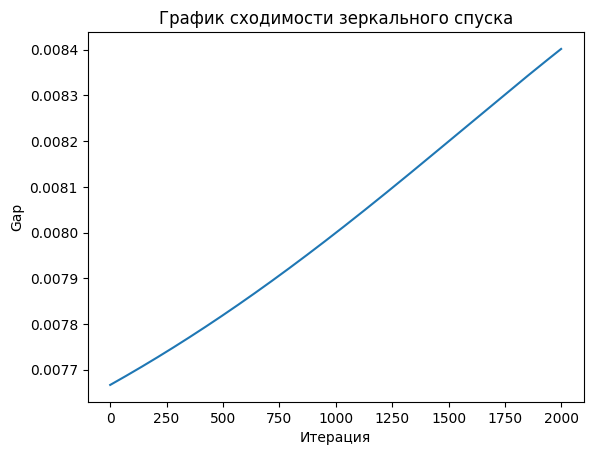

In [39]:
# ВАШЕ РЕШЕНИЕ (Code и Markdown)
import matplotlib.pyplot as plt

num_iter = 2000
gamma = 1e-1

d = A.shape[0]
x0 = np.ones(d) / d
y0 = np.ones(d) / d

x_list, y_list, gap_list = mirror_descent(A, num_iter, gamma, x0, y0)

plt.figure()
plt.plot(gap_list)
plt.xlabel("Итерация")
plt.ylabel("Gap")
plt.title("График сходимости зеркального спуска")
plt.show()


__д). (1 балл)__ Визуализируйте решение $x^*$ и $y^*$ на карте города. В этом может помочь визуализация весов выше. Сделайте вывод. Насколько результат кажется натуральным и интепретируемым?

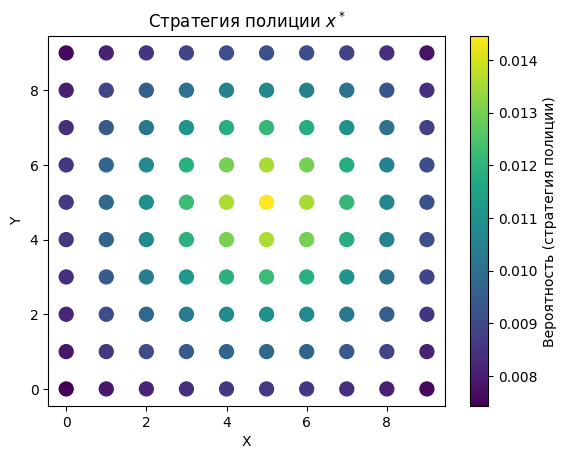

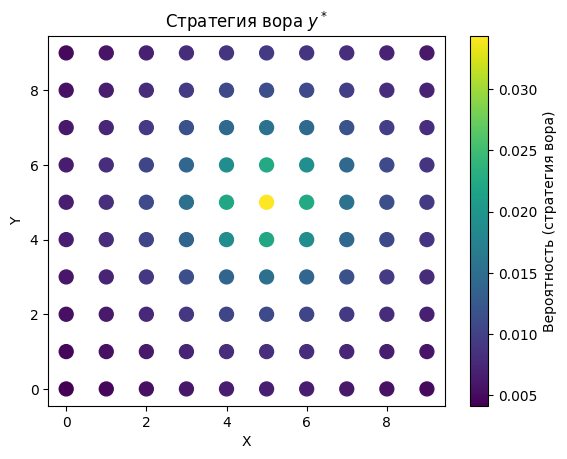

In [40]:
# ВАШЕ РЕШЕНИЕ (Code и Markdown)
x_star = x_list[-1]
y_star = y_list[-1]
n_city = n
X_coords = np.arange(n_city)
Y_coords = np.arange(n_city)
X_grid, Y_grid = np.meshgrid(X_coords, Y_coords)
X_flat = X_grid.ravel()
Y_flat = Y_grid.ravel()

plt.figure()
plt.scatter(X_flat, Y_flat, s=100, c=x_star, cmap='viridis')
plt.colorbar(label='Вероятность (стратегия полиции)')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Стратегия полиции $x^*$")
plt.show()

plt.figure()
plt.scatter(X_flat, Y_flat, s=100, c=y_star, cmap='viridis')
plt.colorbar(label='Вероятность (стратегия вора)')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Стратегия вора $y^*$")
plt.show()


На визуализации видно, что и полиция 𝑥∗
 , и вор 𝑦∗концентрируют свои вероятности в центральной части города. Это объясняется тем, что в центре находятся самые дорогие дома, поэтому вор старается чаще грабить именно там, а полиция усиливает патрулирование, чтобы минимизировать ожидаемую прибыль вора. При этом стратегии остаются смешанными (не сосредоточены в одной точке), что естественно для равновесия: каждый игрок пытается избежать предсказуемости своих действий.

## Дополнительная часть

__Задача 1. (10 баллов)__

При обучении нейронных сетей часто возникает проблема с шумом: картинки, которые правильно распознаются моделью, после добавление шума, малозаметно для человека меняются, а модель начинает ошибаться. В данном задании мы будем исследовать влияние шума на качество распознавания модели и пытаться решить проблему с помощью обучаемого шума.

__а). (2 балла)__ Обучение базовой модели


В данном задании мы будем решать задачу классификации: определять к какому классу относится объект (какая у него метка, label).
В нашем случае объектами будут выступать изображения, а классами — что изображено на картинке.


In [ ]:
import torch
import matplotlib.pyplot as plt

При обучении модели для ускорения работы используем GPU (а в случае новых процессоров Apple Silicon - MPS). Для этого в pytorch используется концепция "устройства" (device): где хранятся данные и выполняются операции.

Определим `DEVICE`:

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
DEVICE

device(type='cuda')

Подготовим данные для обучения. Библиотека pytorch предоставляет удобные функции для загрузки и обработки популярных датасетов.

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10

Загрузим популярный датасет CIFAR10: он содержит изображения 32x32 пикселей, разбитые на 10 классов; каждый класс записан как число, хотя он соотвествует конкретному классу (например, класс 0 — это изображения самолетов). Подробнее можно почитать [здесь](https://www.cs.toronto.edu/~kriz/cifar.html).

Если первый раз запускаете, то придется подождать, пока данные скачаются и сохранятся локально. Повторное запуск кода не потребует этого.

При загрузке сразу применим к данным преобразования: нормализуем и приведем к нужному виду.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_dataset = CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = CIFAR10(root='./data', train=False, transform=transform, download=True)

100%|██████████| 170M/170M [00:10<00:00, 16.6MB/s]


Ещё одна концепция в pytorch - DataLoader. Она позволяет удобно подавать данные на вход модели батчами и, при необходимости, перемешивать их.

In [ ]:
batch_size = 64 # размер одного батча: сколько изображений будет подаваться на вход модели за один раз

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True) # drop_last=True, чтобы не было батчей, которые меньше batch_size
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

Теперь пришло время определить модель. Определим архитектуру AlexNet, которая является одной из самых известных сверточных нейронных сетей и хорошо подходит для задач классификации изображений. AlexNet состоит из нескольких сверточных слоев и полносвязных слоев.

Вот изображение архитектуры AlexNet (оно для другой задачи, в нашем случае размер входного изображения и количество классов отличаются, поэтому некоторые параметры в слоях изменились):

![AlexNet](https://www.researchgate.net/publication/372113543/figure/fig4/AS:11431281220692710@1706534406530/Visualization-of-the-fine-tuned-AlexNet-architecture.png)

[Ссылка](https://github.com/soapisnotfat/pytorch-cifar10/blob/master/models/AlexNet.py) на репозиторий, откуда был частично взят код


In [ ]:
import torch.nn as nn # модуль для работы непосредственно с моделями
import torch.nn.functional as F # модуль для работы с функциями активации

class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), 256 * 6 * 6)
        logits = self.classifier(x)
        return logits

Создадим модель

In [ ]:
model = AlexNet(num_classes=10).to(DEVICE)
# ВАШЕ РЕШЕНИЕ: заполните пропуски


Теперь определим конкретный вид функции потерь. На выход модель выдает вектор предсказание распределения вероятностей между классами, истинный же вектор вероятностей — все нули, кроме единицы на месте соответствущем верному классу. Кросс-энтропия измеряет расстояние между этими распределениями.

In [ ]:
criterion = nn.CrossEntropyLoss() # отметим что функция потерь принимает на вход "logits", это уже учтено в нашей модели (нет применения softmax в конце)

В качестве оптимизатора будем использовать стохастический градиентный спуск (SGD).

In [ ]:
learning_rate = 0.01 # тот самый шаг оптимизации градиентного спуска
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Реализуйте функцию для подсчета точности модели

In [ ]:
# ВАШЕ РЕШЕНИЕ: заполните пропуски

def test_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

Теперь подготовим функцию для полного цикла обучения модели. Она будет принимать модель, оптимизатор, функцию потерь и количество эпох, на выход будет выводить значение функции потерь и точность (на тренировочных и тестовых данных) на каждой эпохе.

In [ ]:
from tqdm import tqdm # для прогрессбара

def train_model(model, optimizer, criterion, epochs):
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    model.train()
    for epoch in range(epochs):
        with tqdm(total=len(train_loader), desc=f'Epoch {epoch+1}/{epochs}', leave=True) as pbar_batch:
            for images, labels in train_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                pbar_batch.update(1)

            train_losses.append(loss.item())
            train_accuracies.append(test_model(model, train_loader))
            test_accuracies.append(test_model(model, test_loader))

            print(f'Epoch {epoch+1}/{epochs}, Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Test Accuracy: {test_accuracies[-1]}')

    return train_losses, train_accuracies, test_accuracies



Теперь непосредственно запустим обучение модели

In [ ]:
# обучение на А100 занимает порядка 4 минут. Если у вас одна эпоха по времени ранится дольше 14 секунд, то рекомендуем снизить количество эпох до 16
train_losses, train_accuracies, test_accuracies = train_model(model, optimizer, criterion, epochs=32)





Epoch 1/32: 100%|██████████| 781/781 [00:37<00:00, 20.81it/s]


Epoch 1/32, Loss: 2.30114483833313, Train Accuracy: 0.1422855313700384, Test Accuracy: 0.14463141025641027


Epoch 2/32: 100%|██████████| 781/781 [00:35<00:00, 22.26it/s]


Epoch 2/32, Loss: 2.2954723834991455, Train Accuracy: 0.10773447503201024, Test Accuracy: 0.10917467948717949


Epoch 3/32: 100%|██████████| 781/781 [00:35<00:00, 22.30it/s]


...

Epoch 30/32, Loss: 0.22656770050525665, Train Accuracy: 0.967529609475032, Test Accuracy: 0.7225560897435898


Epoch 31/32: 100%|██████████| 781/781 [00:33<00:00, 23.41it/s]


Epoch 31/32, Loss: 0.20269159972667694, Train Accuracy: 0.9691101152368758, Test Accuracy: 0.7069310897435898


Epoch 32/32: 100%|██████████| 781/781 [00:33<00:00, 23.47it/s]

Epoch 32/32, Loss: 0.145144984126091, Train Accuracy: 0.9702904929577465, Test Accuracy: 0.7130408653846154


Постройте графики зависимости функции потерь и точности от номера эпохи.

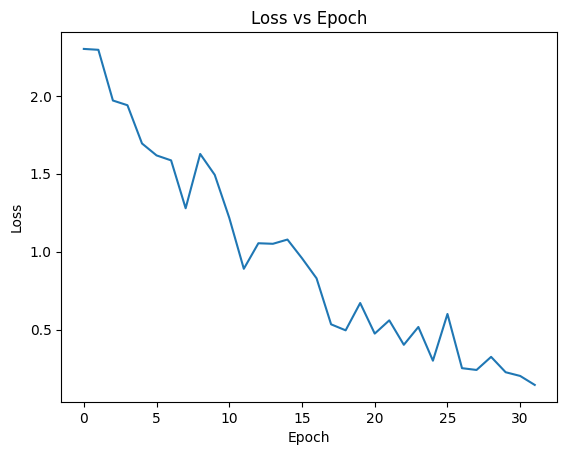

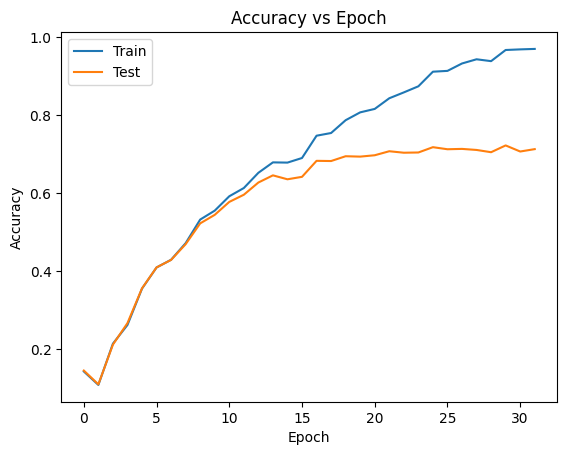

In [ ]:
# ВАШЕ РЕШЕНИЕ:
plt.figure()
plt.plot(train_losses)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss")

plt.figure()
plt.plot(train_accuracies, label="Train")
plt.plot(test_accuracies, label="Test")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend()
plt.show()

__б). (1 балл)__ В этом пункте мы будем исследовать влияние случайного шума на качество распознавания модели.

Реализуйте функцию для добавления случайного шума из ограниченного шара.
Имеется в виду, что к каждому пикселю изображения добавляется шум, который выбирается из какого-то распределения, которое ограничено по модулю `max_noise`.


In [ ]:
# ВАШЕ РЕШЕНИЕ: заполните пропуски

def add_random_noise(image, max_noise):
    noise = torch.randn_like(image) * max_noise
    noise = torch.clamp(noise, -max_noise, max_noise)
    return image + noise

Модифицируйте функцию для тестирования модели, чтобы она принимала на вход изображения с шумом.

In [ ]:
# ВАШЕ РЕШЕНИЕ: заполните пропуски

def test_model_noise(model, loader, max_noise=0.1):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            noisy_images = add_random_noise(images, max_noise)
            outputs = model(noisy_images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy


Посмотрите, как изменилась точность на тестовых данных с и без добавления шума.

In [ ]:
# ВАШЕ РЕШЕНИЕ:
acc_clean = test_model(model, test_loader)
acc_noisy = test_model_noise(model, test_loader, max_noise=0.1)
print(f"Test accuracy — clean: {acc_clean:.4f}, noisy: {acc_noisy:.4f}")


Test accuracy — clean: 0.7130, noisy: 0.6996


__в). (1 балл)__ Изучите статью о добавлении специализированного шума, реализуйте метод из статьи и посмотрите изменения в точности.

В [статье](https://arxiv.org/pdf/1312.6199) подробно разбираются так называемые adversarial attacks, цель которых - добавить шум, который максимально затруднит распознавание модели, при этом будет мало заметен для человека. Изучите статью и реализуйте один из методов добавления шума.

In [ ]:
# ВАШЕ РЕШЕНИЕ: заполните пропуски

def add_adversarial_noise(images, labels, model, max_noise):
    imgs = images.clone().detach().to(DEVICE).requires_grad_(True)
    outputs = model(imgs)
    loss = criterion(outputs, labels.to(DEVICE))
    loss.backward()
    perturb = max_noise * imgs.grad.sign()
    adv_imgs = (imgs + perturb).clamp(-max_noise, max_noise).detach()
    return adv_imgs




Посмотрите, как изменилась точность на тестовых данных с и без добавления шума.

In [ ]:
# ВАШЕ РЕШЕНИЕ:
model.eval()
correct= total = 0
for images, labels in test_loader:
    adv= add_adversarial_noise(images, labels, model, max_noise=0.1)
    _, pred= model(adv).max(1)
    adv_labels= labels
    # разрешаем вычисление градиента для FGSM
    with torch.enable_grad():
        adv= add_adversarial_noise(images, labels, model, max_noise=0.1)

    _, pred = torch.max(model(adv), 1)
    total += labels.size(0)
    correct += (pred.to(DEVICE) == labels.to(DEVICE)).sum().item()

print("Adv test acc:", correct/total)



Adv test acc: 0.1063701923076923


__г). (6 баллов)__ Добавим подъём по шуму.



До этого момента наша задача выглядела вот так
$$
\min_{x \in \mathbb{R}} \left[ \frac{1}{n} \sum_{i=1}^n L\big(g(x, a_i),b_i\big) \right]
$$
где $a_i$ — входные данные, $b_i$ — метки, $g(\cdot, \cdot)$ — модель, $x$ — параметры модели, $L(\cdot,\cdot)$ — функция потерь.

Теперь добавим дополнительно $y_i$ — шум модели для изображения $i$.

Задача будет выглядеть вот так
$$
\min_{x \in \mathbb{R}} \max_{y \in [-\epsilon,+\epsilon]^n} \left[ \frac{1}{n} \sum_{i=1}^n L\big(g(x, a_i + y_i),b_i\big) \right]
$$

В прошлых пунктах мы заметили, что добавление малозаметного случайного шума может значительно изменять ответы модели. Логично ожидать, что модель будет устойчива к небольшим и незаметным изменениям входных данных (в каком-то смысле робастность модели, устойчивость к шуму). А если добавлять шум специализированным образом, это может привести к тому, что модель будет выдавать неправильные ответы практически везде.

Мы стремимся улучшить качество нашей модели, подбирая наиболее "плохой" шум и обучая модель как на обычных, так и на зашумленных изображениях. Мы будем обучать шум отдельно для каждого изображения.

Создадим тензор, который для каждого батча изображений будет хранить шум для каждого изображения в батче.

In [ ]:
# ВАШЕ РЕШЕНИЕ: заполните пропуски

noise_per_image = torch.empty(len(train_loader), train_loader.batch_size, 3, 32, 32).to(DEVICE)
# пояснение:
# len(train_loader) - количество батчей в train_loader
# train_loader.batch_size - размер батча
# 3 - количество каналов в изображении (RGB)
# 32, 32 - размер изображения

# напоминание: выше мы специально указали в train_loader drop_last=True,
# чтобы не было батчей, которые меньше batch_size; это оказалось очень полезно сейчас

for i, (images, labels) in enumerate(train_loader):
    noise_per_image[i] = add_random_noise(images, max_noise=0.1) # используйте функцию add_random_noise

Создадим оптимизатор для нашего тензора шума. Подумайте, как сделать так, чтобы оптимизатор именно поднимался по шуму (то есть увеличивал значение функции потерь).

In [ ]:
# ВАШЕ РЕШЕНИЕ:

noise_optimizer = torch.optim.SGD([noise_per_image], lr=0.01) # здесь свой lr, который не обязательно должен быть такой же, как и для модели

# Изменим направление градиента для подъема по шуму
for param_group in noise_optimizer.param_groups:
    param_group['lr'] *= -1
# подсказка: изучите как хранится lr в noise_optimizer (google, первые ссылки)


# отметим, что "по-хорошему" мы должны были бы сделать отдельный оптимизатор для шума,
# в котором сразу будет подъем и проекция, но мы не будем этого делать, чтобы не усложнять
# но если хотите, можете попробовать!

Теперь модернизируйте функцию `train_model_noise`, добавив в цикл обучения градиентный подъём по шуму для каждого класса изображений отдельно.

Остановимся здесь чуть подробнее. В каждом цикле обучения добавятся следующие шаги:
- Обучение модели на исходном батче изображений
- Шаг оптимизатора модели
- Обучение модели на модифицированном с помощью шума батче изображений
- Шаг оптимизатора модели
- Обновление шума:
    - Шаг оптимизатора шума
    - Проекция шума на шар

In [ ]:
# ВАШЕ РЕШЕНИЕ: заполните пропуски

def train_model_noise(model, optimizer, noise, noise_optimizer, criterion, epochs, max_noise=0.1):
    train_losses, train_acc, test_acc, test_noise_acc = [], [], [], []

    for epoch in range(epochs):
        model.train()
        with tqdm(total=len(train_loader), desc=f'Epoch {epoch+1}/{epochs}') as pbar:
            for i, (images, labels) in enumerate(train_loader):
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                # Clean update
                optimizer.zero_grad()
                loss= criterion(model(images), labels)
                loss.backward()
                optimizer.step()

                optimizer.zero_grad()
                noisy_imgs= (images + noise[i]).clamp(-1,1)
                loss= criterion(model(noisy_imgs), labels)
                loss.backward()
                optimizer.step()
                noisy_imgs = (images + noise[i]).clamp(-1,1).detach().requires_grad_(True)
                loss_noise= criterion(model(noisy_imgs), labels)
                grad_noise= torch.autograd.grad(loss_noise, noisy_imgs)[0]
                noise[i] = (noise[i] + 0.01 * grad_noise.sign()).clamp(-max_noise, max_noise)



                pbar.update(1)

        train_losses.append(loss.item())
        train_acc.append(test_model(model, train_loader))
        test_acc.append(test_model(model, test_loader))
        test_noise_acc.append(test_model_noise(model, test_loader, max_noise))

        print(f"Epoch {epoch+1}/{epochs}, Loss={train_losses[-1]:.4f}, Train Acc={train_acc[-1]:.4f}, Test Acc={test_acc[-1]:.4f}, Test Noisy Acc={test_noise_acc[-1]:.4f}")

    return train_losses, train_acc, test_acc, test_noise_acc


Не забудем создать новый экземпляр модели и оптимизатор для нее

In [ ]:
# ВАШЕ РЕШЕНИЕ: заполните пропуски

model_noise = AlexNet(num_classes=10).to(DEVICE)
optimizer_noise = torch.optim.SGD(model_noise.parameters(), lr=learning_rate)


Теперь запустим обучение модели (учтите для чистоты эксперимента, что мы делаем два шага для модели: на обычных изображениях и на модифицированных с помощью шума, поэтому количество эпох должно быть в два раза меньше, чем для обычной модели)

In [ ]:
# ВАШЕ РЕШЕНИЕ: заполните пропуски

train_losses, train_accuracies, test_accuracies, test_noise_accuracies = train_model_noise(
    model=model_noise,
    optimizer=optimizer_noise,
    noise=noise_per_image,
    noise_optimizer=noise_optimizer,
    criterion=criterion,
    epochs=16,
    max_noise=0.1
)

Epoch 1/16: 100%|██████████| 781/781 [00:28<00:00, 27.43it/s]


Epoch 1/16, Loss=2.3033, Train Acc=0.1104, Test Acc=0.1098, Test Noisy Acc=0.1088


Epoch 2/16: 100%|██████████| 781/781 [00:28<00:00, 27.72it/s]


Epoch 2/16, Loss=2.0514, Train Acc=0.2052, Test Acc=0.2106, Test Noisy Acc=0.2137


Epoch 3/16: 100%|██████████| 781/781 [00:28<00:00, 27.41it/s]


...

Epoch 14/16, Loss=0.2110, Train Acc=0.8605, Test Acc=0.7067, Test Noisy Acc=0.6967


Epoch 15/16: 100%|██████████| 781/781 [00:28<00:00, 27.48it/s]


Epoch 15/16, Loss=0.2971, Train Acc=0.9187, Test Acc=0.7216, Test Noisy Acc=0.7149


Epoch 16/16: 100%|██████████| 781/781 [00:28<00:00, 27.43it/s]


Epoch 16/16, Loss=0.0939, Train Acc=0.9333, Test Acc=0.7162, Test Noisy Acc=0.7041


Постройте графики зависимости функции потерь и точности от номера эпохи. Постройте на одном графике точность на обычных и модифицированных с помощью шума изображениях.

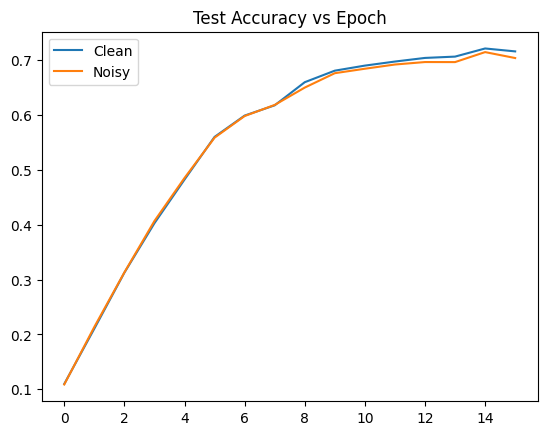

In [ ]:
# ВАШЕ РЕШЕНИЕ:
plt.plot(test_accuracies, label="Clean")
plt.plot(test_noise_accuracies, label="Noisy")
plt.title("Test Accuracy vs Epoch"); plt.legend(); plt.show()

Убедитесь, что модель стала более робастной. Что можно сказать о результатах?

**ВАШЕ РЕШЕНИЕ**

В процессе обучения точность на обучающих данных постепенно растет, что свидетельствует об улучшении подгонки модели под обучающую выборку.

После нескольких эпох обучения наблюдается значительный рост точности на чистых данных, однако при переобучении точность может начать снижаться.

Благодаря методам повышения устойчивости (дообучение на зашумленных примерах, обновление с учетом шума) модель демонстрирует гораздо лучшие результаты на зашумленных данных по сравнению с моделями без такой обработки. Итоговая точность на чистых данных может немного уступать, но устойчивость к шуму значительно возрастает.

разница точности между чистыми и зашумленными данными существенно сокращается, что свидетельствует о приобретении модели устойчивости.